In [1]:
import glob
import os

import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
import train

from matplotlib import pyplot as plt
from plottingtool import plot_1d_hist, plot_2d_hist, plot_2d_res_hist

import mplhep as hep
hep.style.use("ATLAS")

In [2]:
fold  = "fold0"
# ckpt_files = glob.glob(f"./hww_pcres_regressor_kfold/{fold}/version_0/checkpoints/*.ckpt")
ckpt_files = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/checkpoints/*.ckpt")
print(f"Found checkpoint files: {ckpt_files}")
if not ckpt_files: 
    raise FileNotFoundError(f"No checkpoint files found in checkpoints")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Found checkpoint files: ['./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=691-val_loss=19.88.ckpt']
Using checkpoint: ./hww_pcres_regressor_nofold/logs/version_0/checkpoints/reg-epoch=691-val_loss=19.88.ckpt


In [3]:
# Retrieve datamodule used in training
# train = two_fold_train
dm = train.main(train=False)
# Load model from checkpoint
model = LightningWBoson.load_from_checkpoint(ckpt_path, weights_only=False, strict=False)
model.eval() # used to inference -> not for training phase

# Set up the data module (prepare data and setup splits)
dm.setup(stage="test")  # Ensure test dataset is ready
# Get the test dataloader
test_loader = dm.test_dataloader()

# Run inference
train_features = np.zeros([0, dm.X.shape[1]])
predictions = np.zeros([0, dm.Y.shape[1]-2]) # without including W0 and W1 mass
true_labels = np.zeros([0, dm.Y.shape[1]])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():  # Disable gradient computation for inference
    for batch in test_loader:
        # Assuming batch contains inputs and targets
        inputs, targets = batch
        # print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Store predictions and true labels
        train_features = np.append(train_features, inputs.cpu().numpy(), axis=0)
        predictions = np.append(predictions, outputs.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, targets.cpu().numpy(), axis=0)

Seed set to 114


Evaluation mode, loading checkpoints...
Using HDF5 categories: ggF_test, ggF_train, ggF_val
Training objects shape: (376985, 26)
Target objects shape: (376985, 10)
Removed 0 rows with NaN or infinite values
Using 10 workers in data loading.
Using random split (val_frac / test_frac)
Loading model from checkpoint for evaluation... return datamodule
Using 4 SA blocks.
Using random split (val_frac / test_frac)


In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, -2]
true_met_py = train_features[:, -1]

In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = np.exp(predictions[..., 3])
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = np.exp(predictions[..., 7])
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = np.exp(true_labels[..., 3])
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = np.exp(true_labels[..., 7])
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

/tmp/ipykernel_501318/2513785030.py:10: RuntimeWarning: invalid value encountered in sqrt
  true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


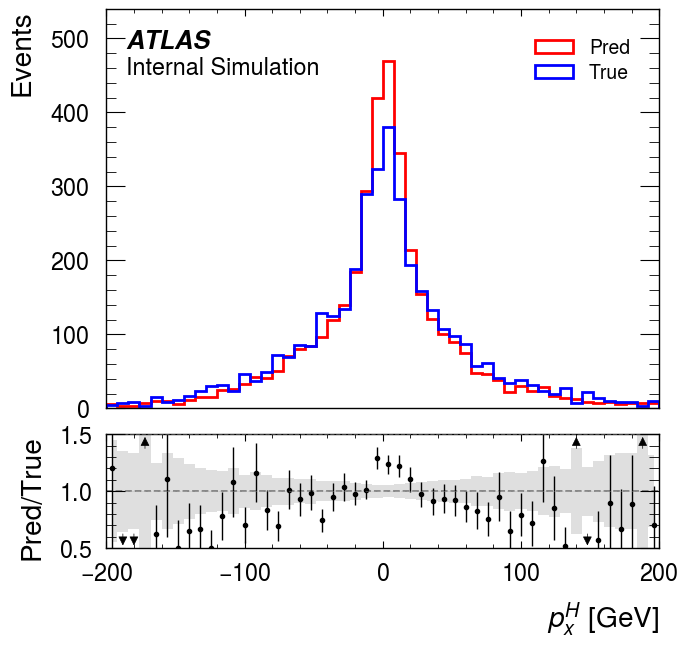

Rel err < 20%: 29.40 %


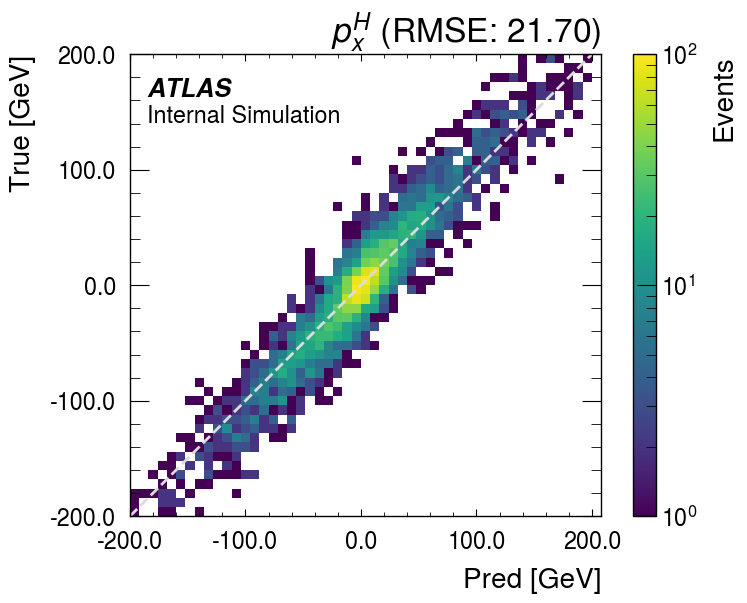

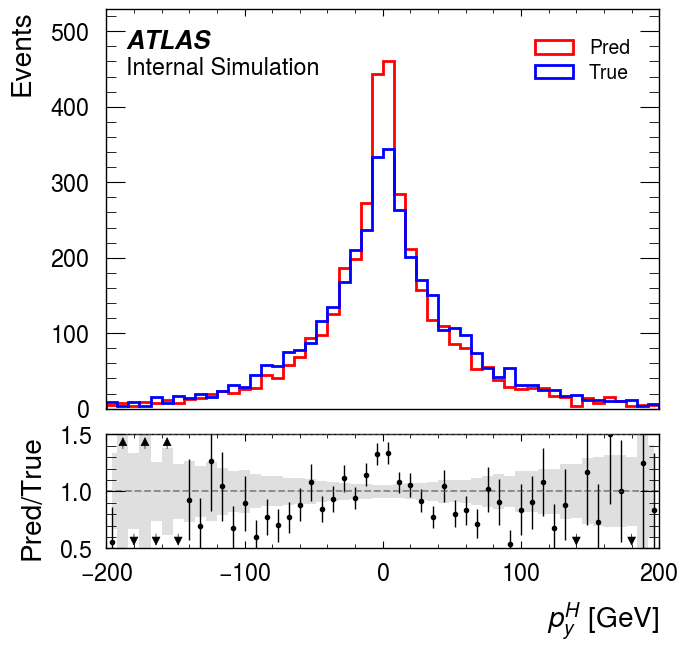

Rel err < 20%: 30.17 %


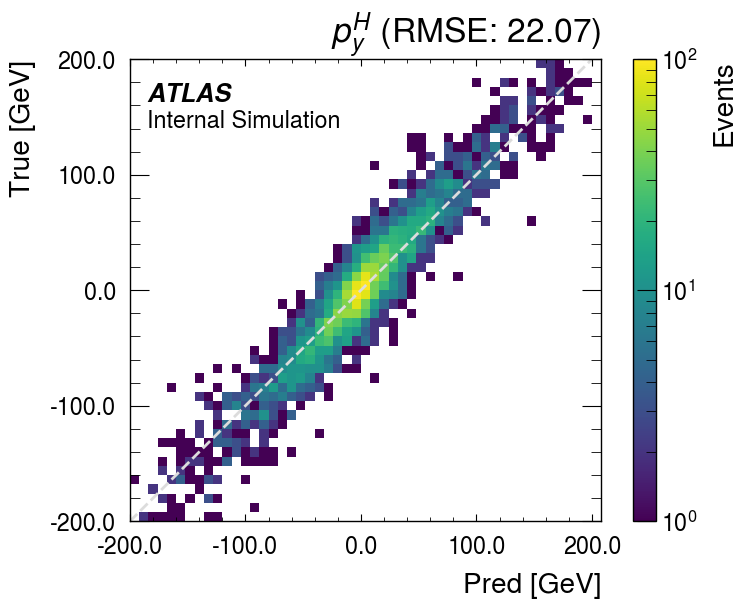

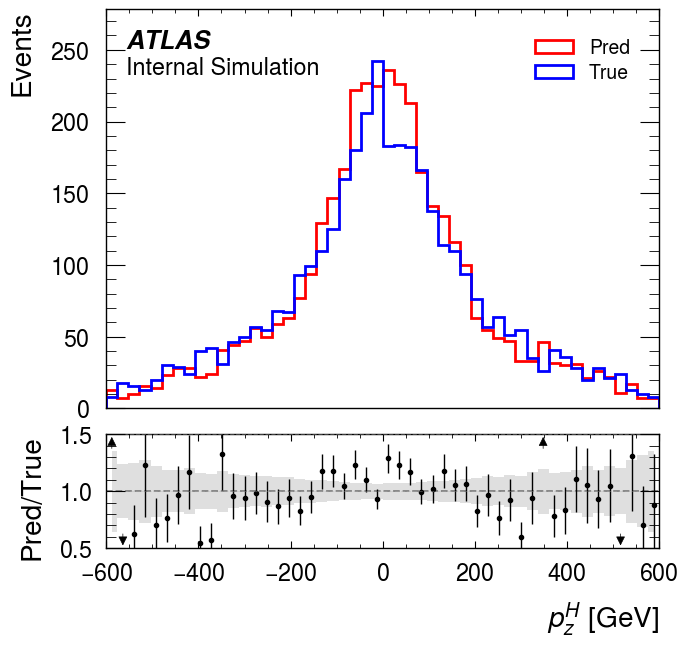

Rel err < 20%: 32.63 %


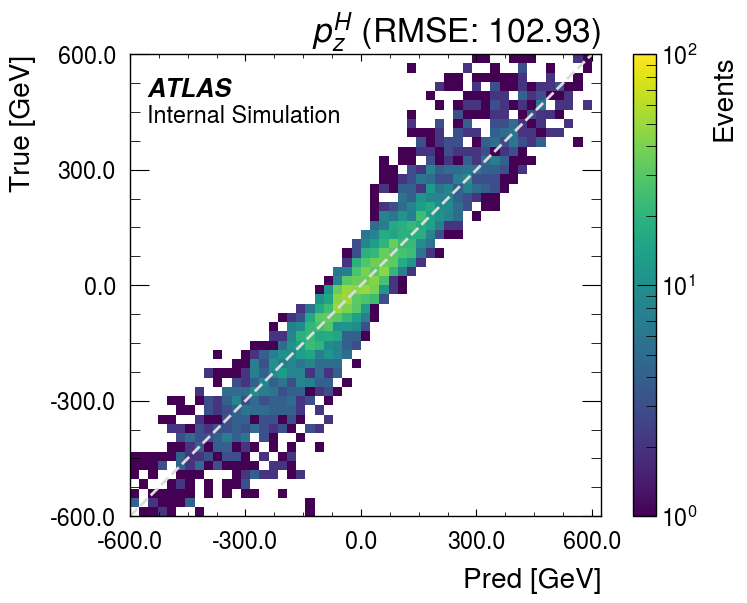

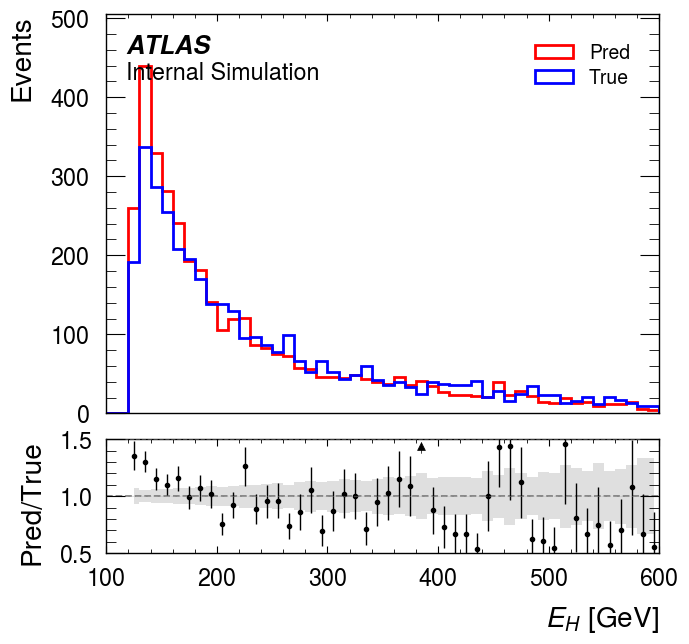

Rel err < 20%: 74.64 %


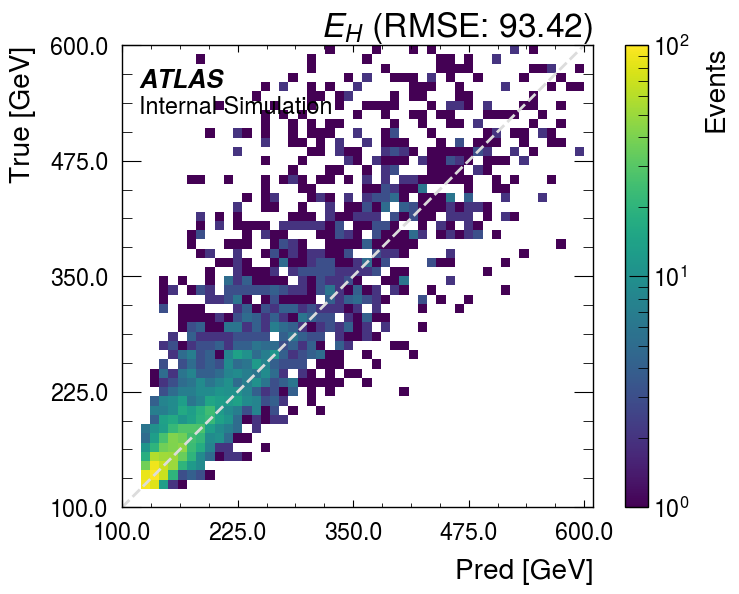

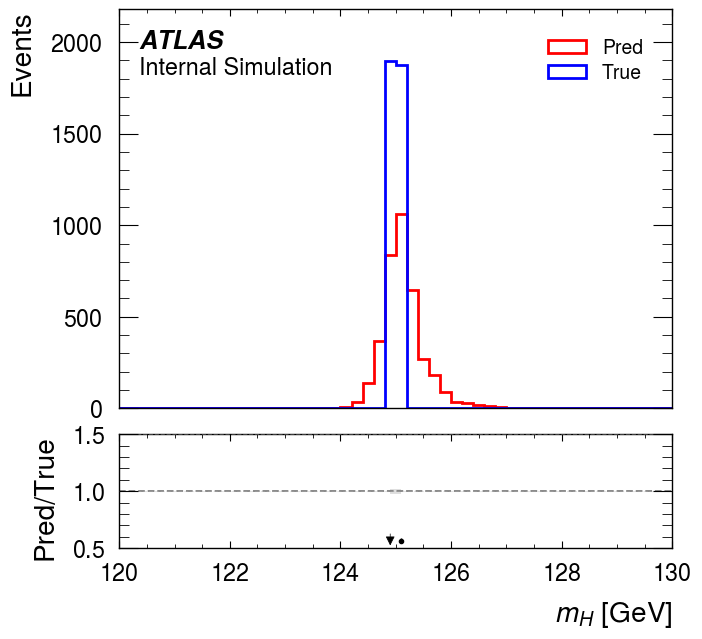

Mean predicted Higgs mass: 125.13 GeV, Std: 0.47 GeV
Rel err < 20%: 99.95 %


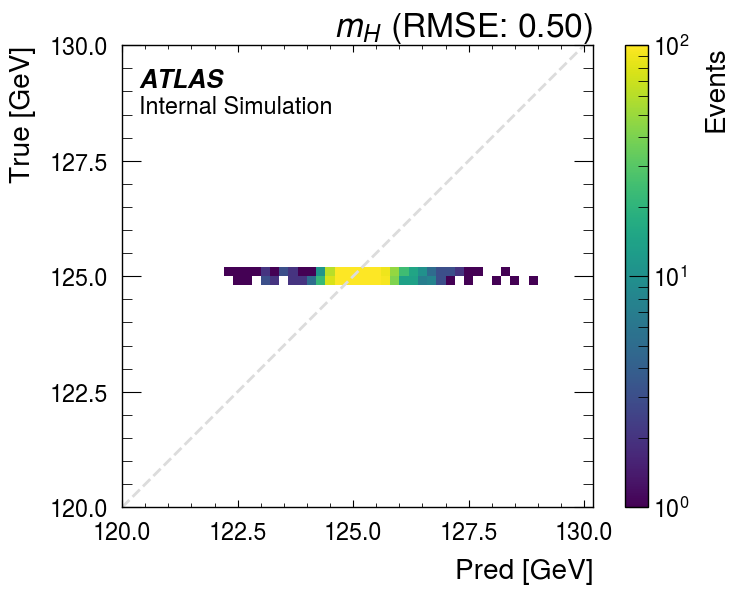

In [6]:
pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass = np.sqrt(pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2))
true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass = np.sqrt(true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2))


plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV")
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
print(f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, Std: {pred_higgs_mass.std():.2f} GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV")

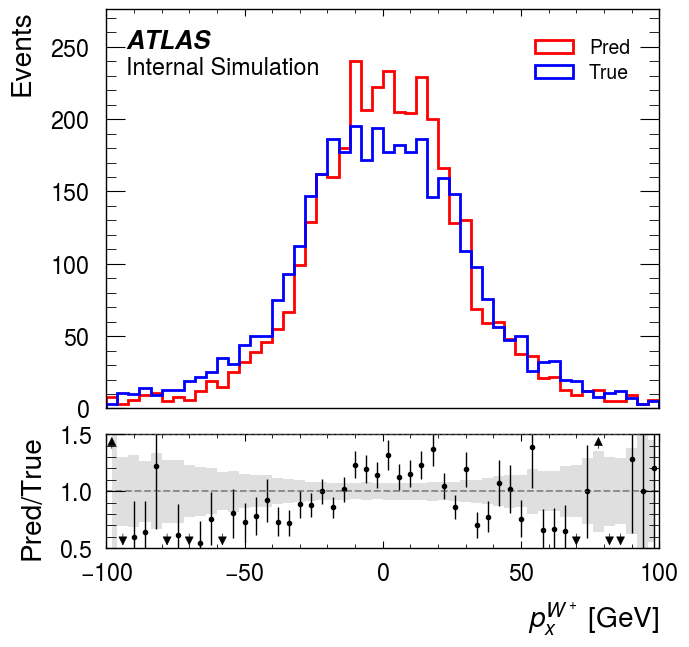

Rel err < 20%: 25.66 %


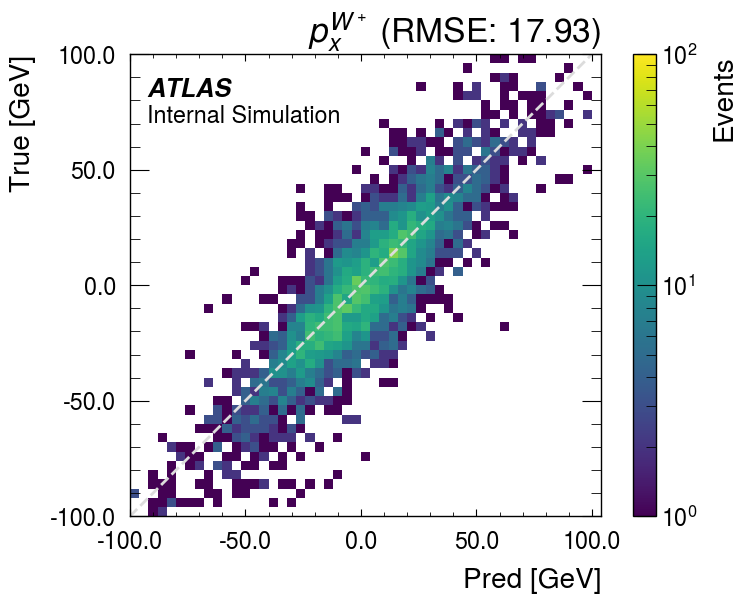

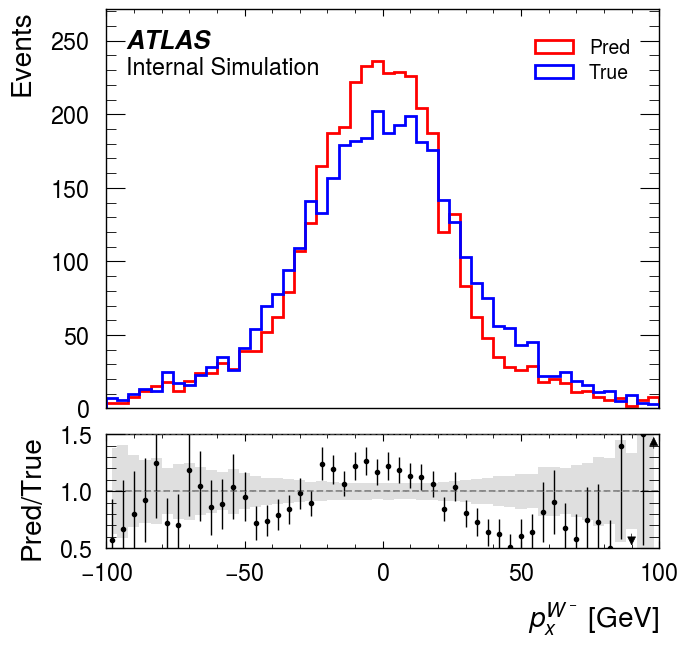

Rel err < 20%: 23.19 %


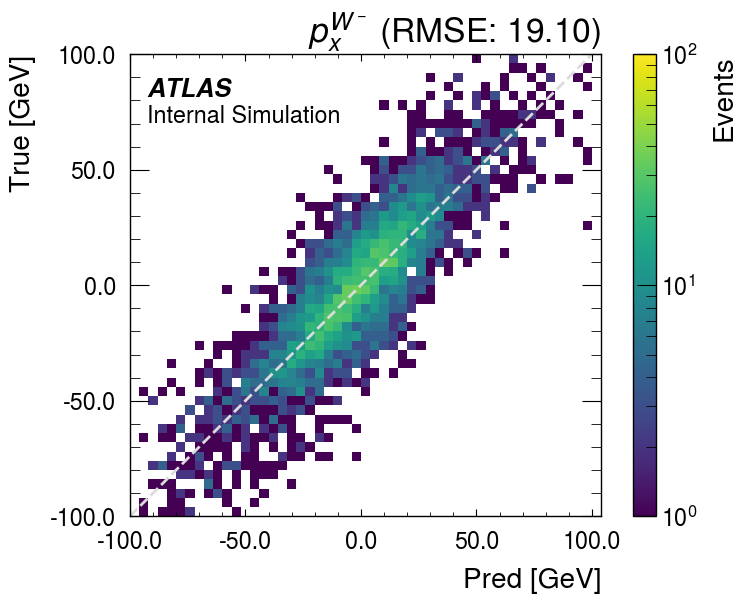

In [7]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True)

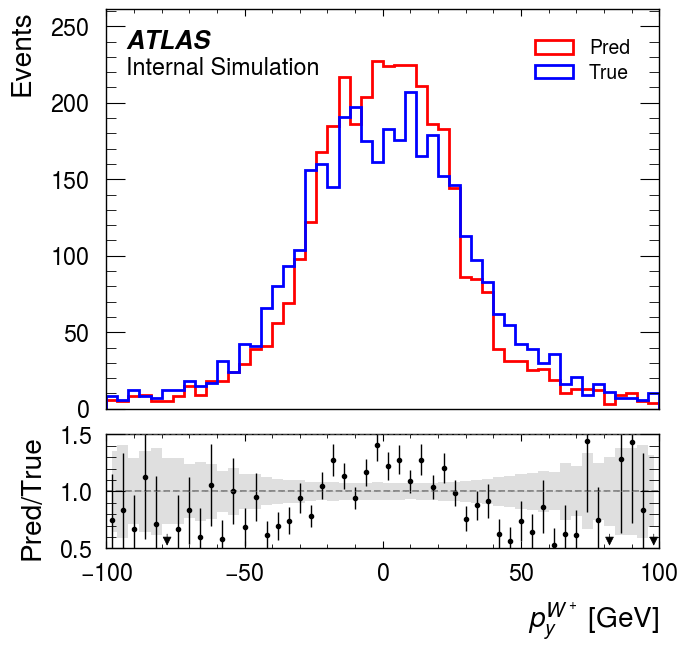

Rel err < 20%: 26.37 %


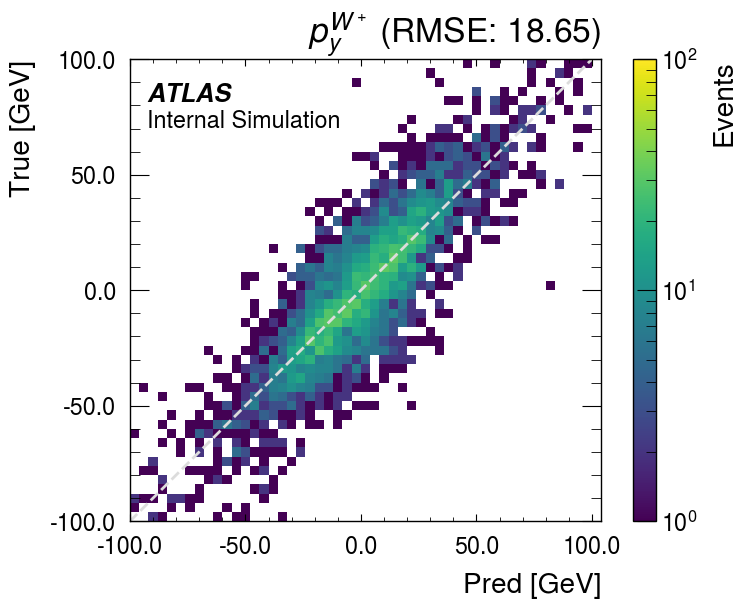

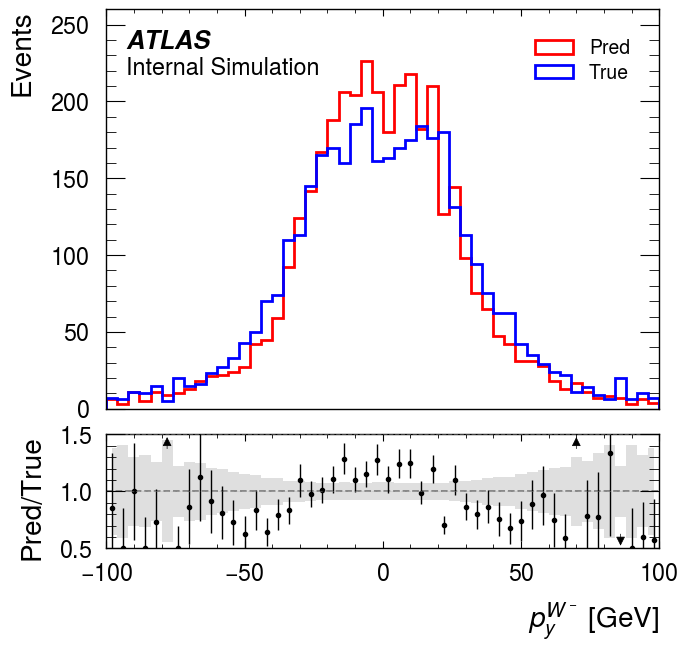

Rel err < 20%: 28.31 %


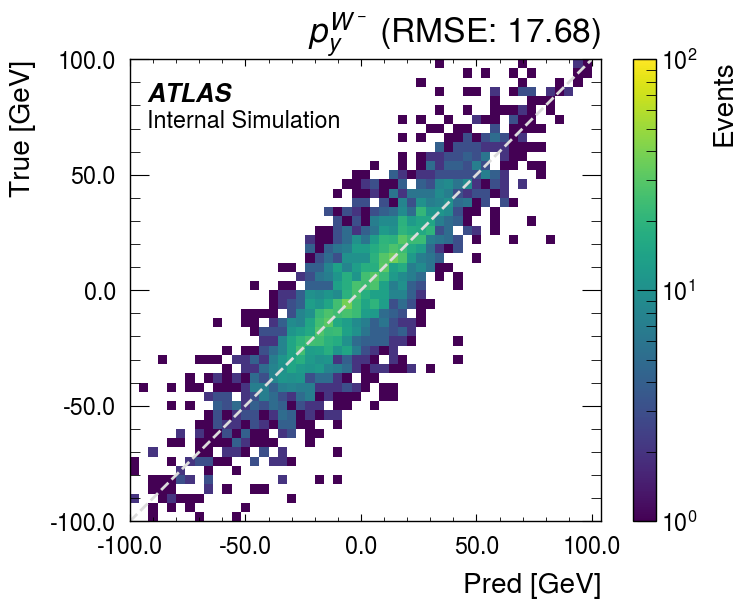

In [8]:
bins = np.linspace(-100, 100, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True)

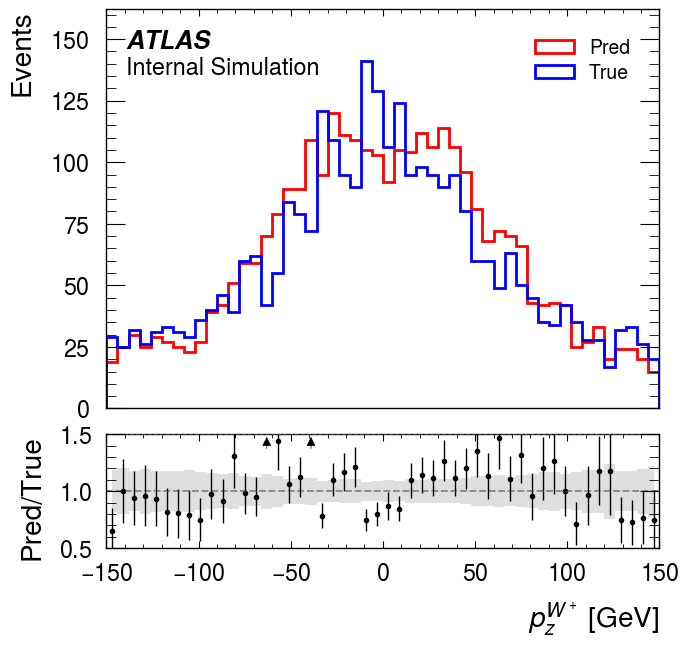

Rel err < 20%: 29.27 %


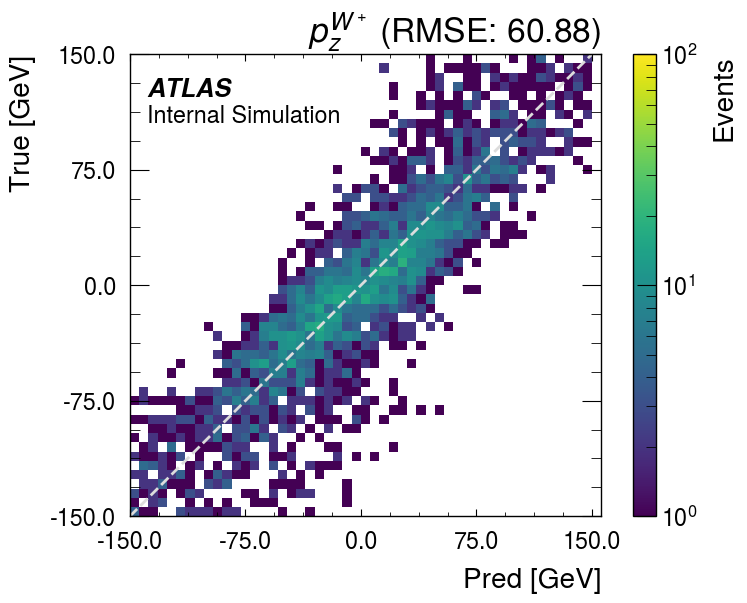

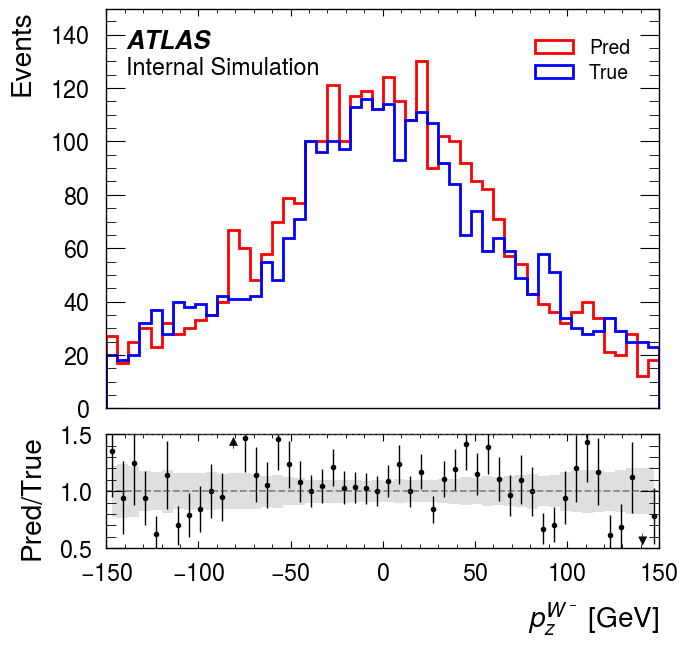

Rel err < 20%: 28.31 %


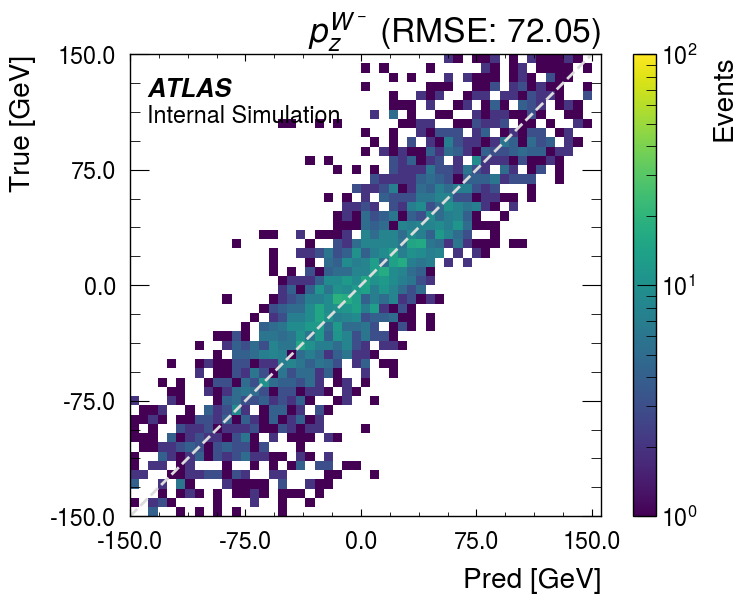

In [9]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True)

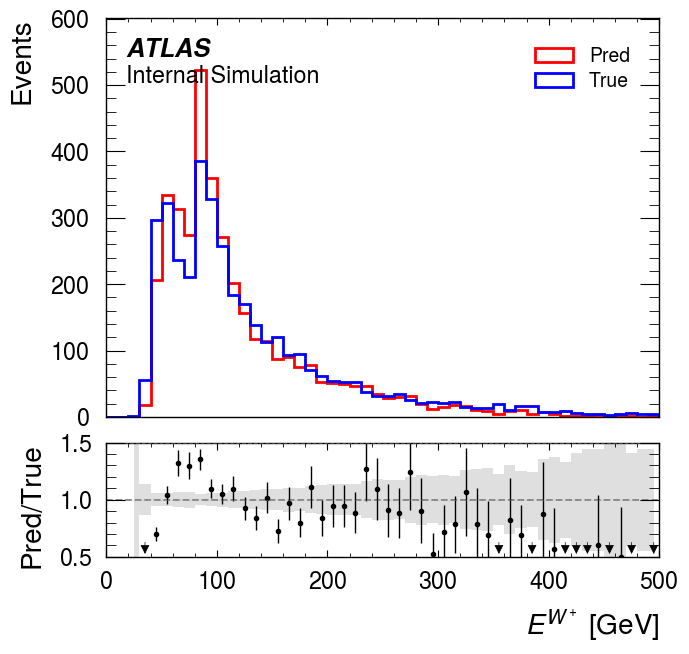

Rel err < 20%: 58.80 %


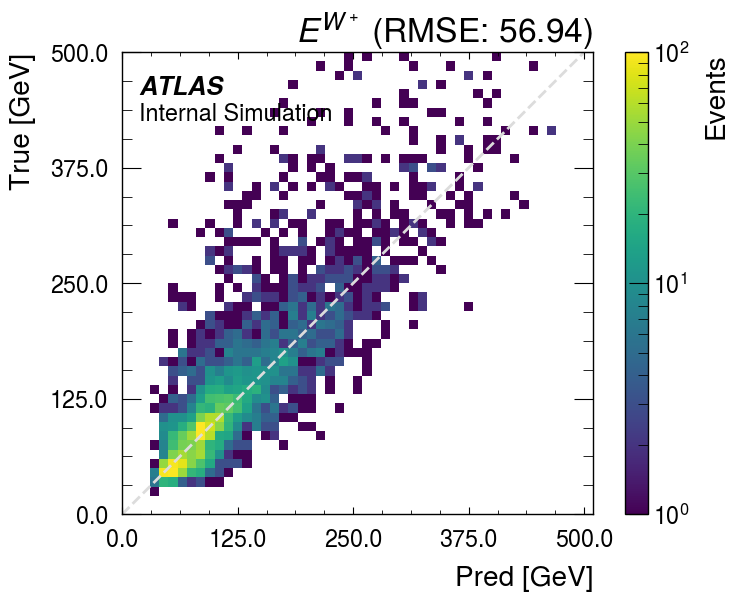

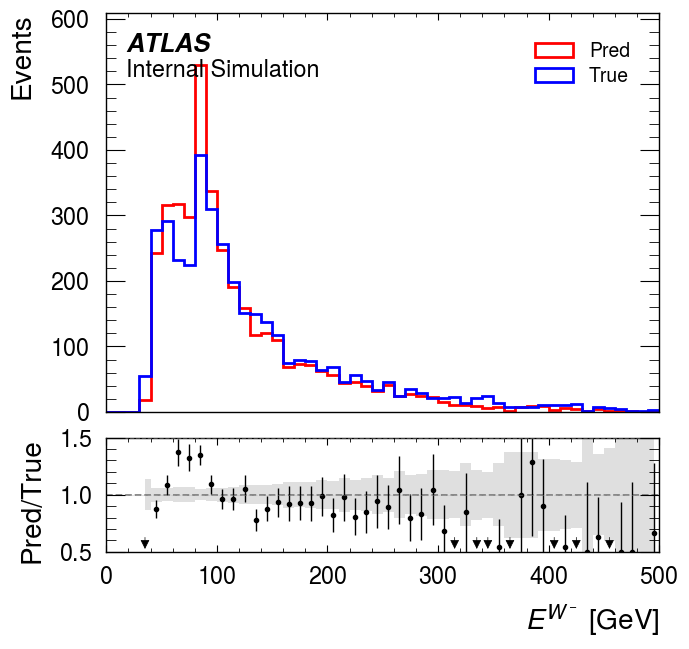

Rel err < 20%: 58.32 %


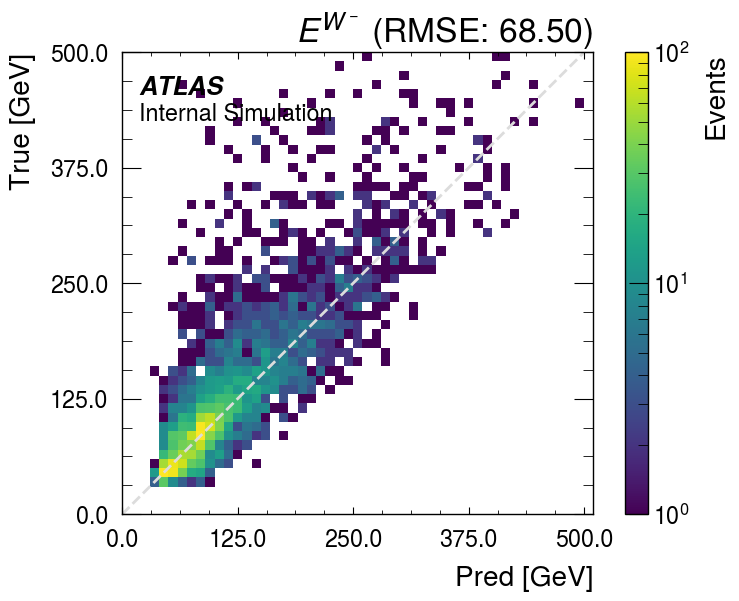

In [10]:
bins = np.linspace(0, 500, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black")
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black")

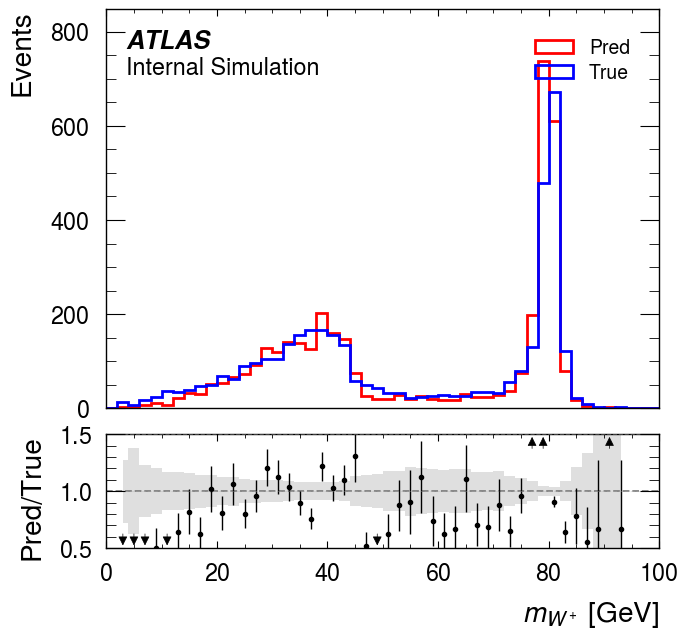

Rel err < 20%: 57.39 %


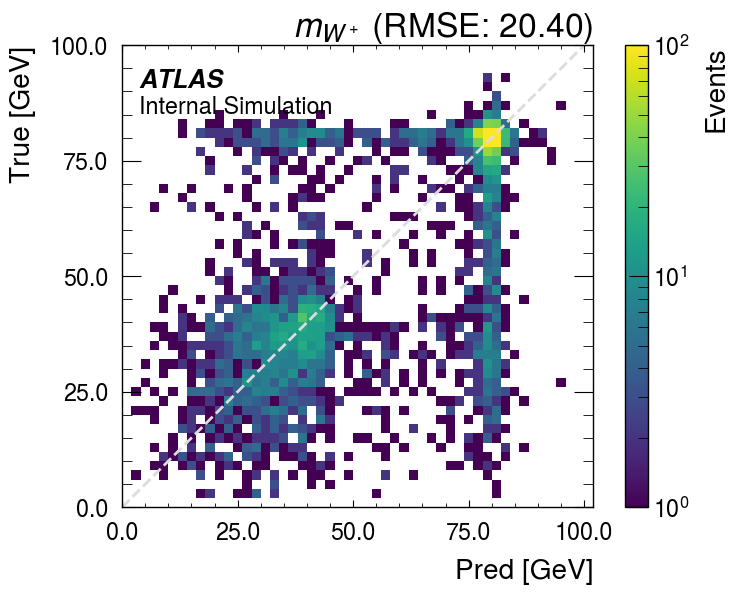

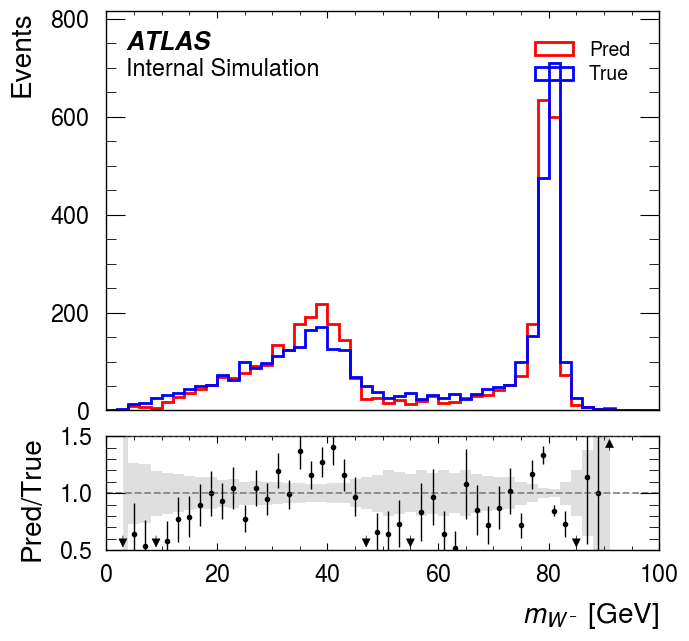

Rel err < 20%: 57.47 %


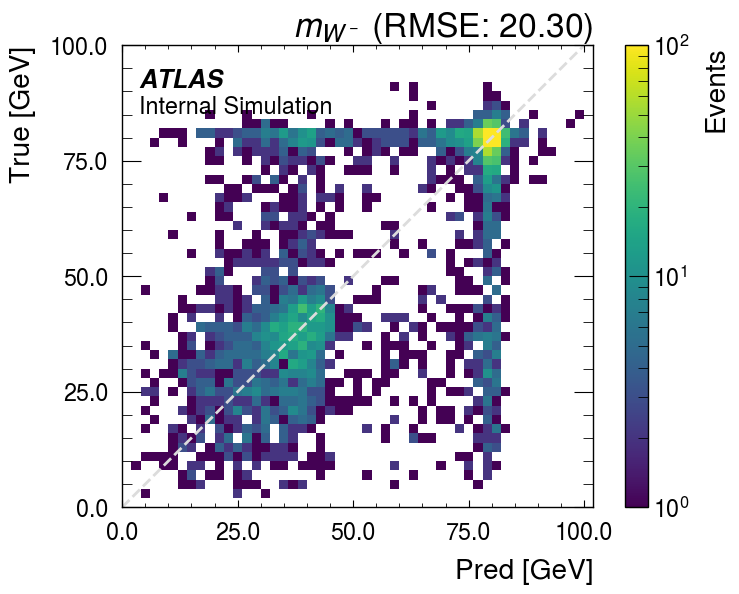

In [11]:
bins = np.linspace(0, 100, 51)
plot_1d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w0_mass_2), np.sqrt(true_w0_mass_2), name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV")
plot_1d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(np.sqrt(pred_w1_mass_2), np.sqrt(true_w1_mass_2), name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV")

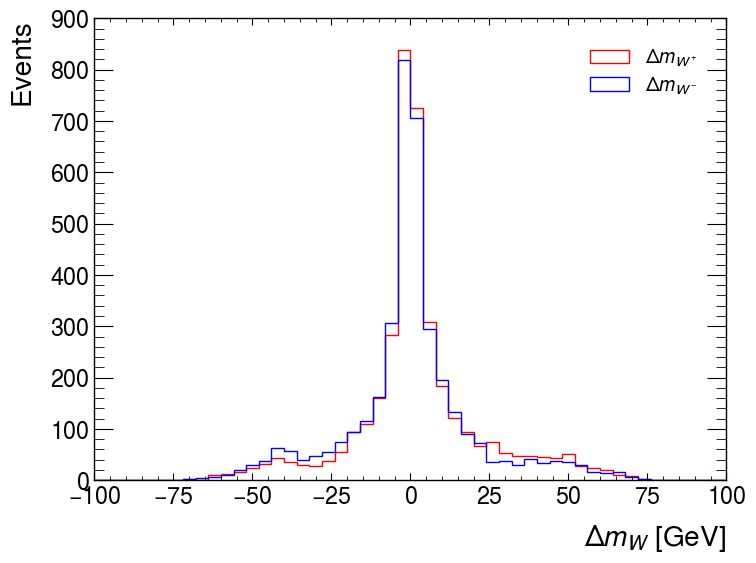

In [12]:
diff_mass_pos = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
diff_mass_neg = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
bins_edges = np.linspace(-100, 100, 51)
plt.hist(diff_mass_pos, bins=bins_edges, histtype='step', color='red',label=r"$\Delta m_{W^+}$")
plt.hist(diff_mass_neg, bins=bins_edges, histtype='step', color='blue',label=r"$\Delta m_{W^-}$")
plt.xlabel(r"$\Delta m_W$ [GeV]")
plt.ylabel("Events")
plt.legend()
plt.show()

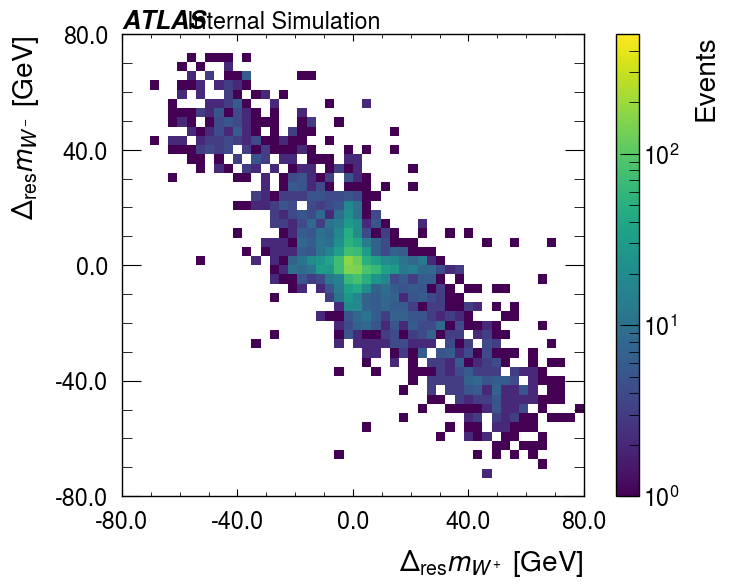

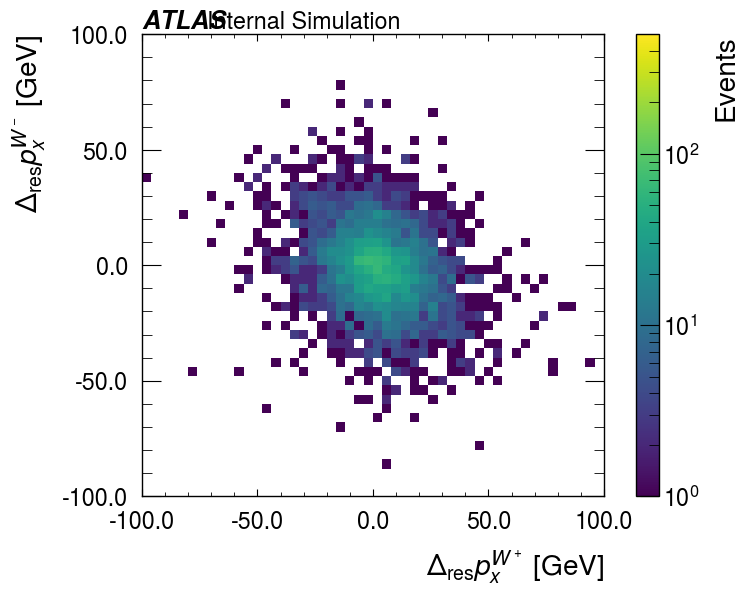

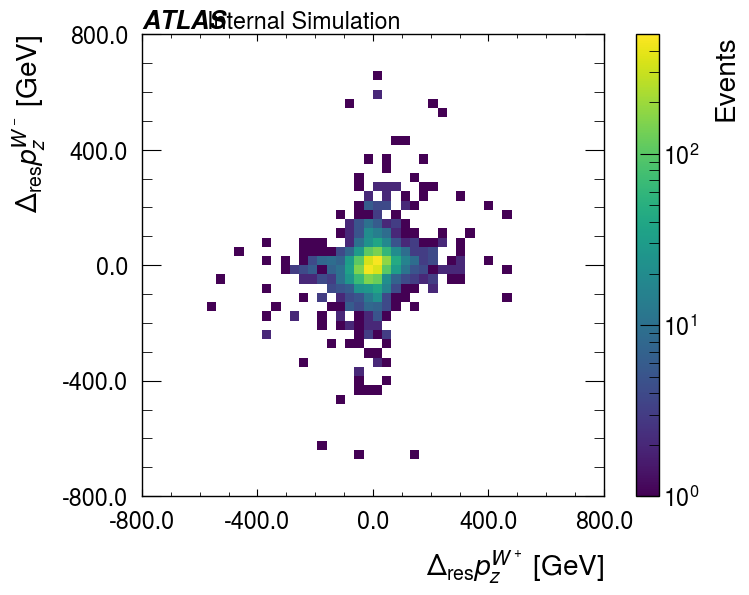

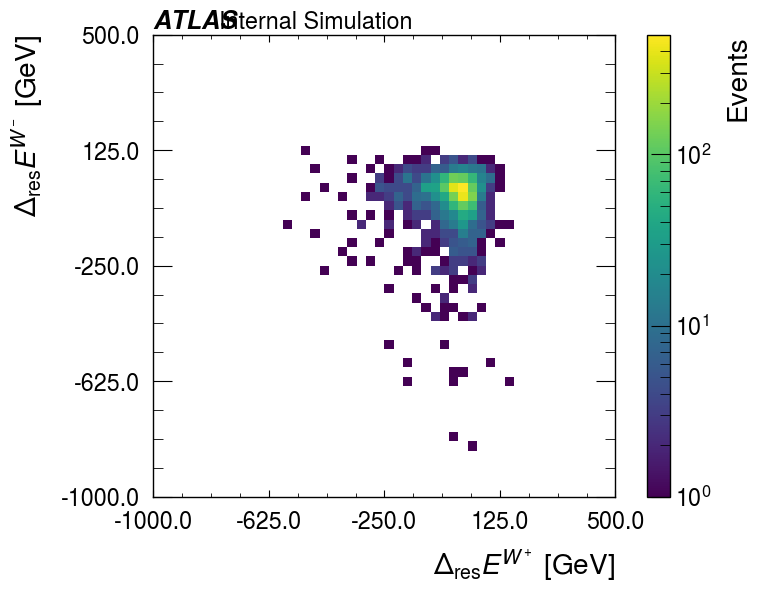

In [13]:
w0_mass_res = np.sqrt(pred_w0_mass_2) - np.sqrt(true_w0_mass_2)
w1_res = np.sqrt(pred_w1_mass_2) - np.sqrt(true_w1_mass_2)
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=5e2)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=5e2)

In [14]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_501318/4229498418.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


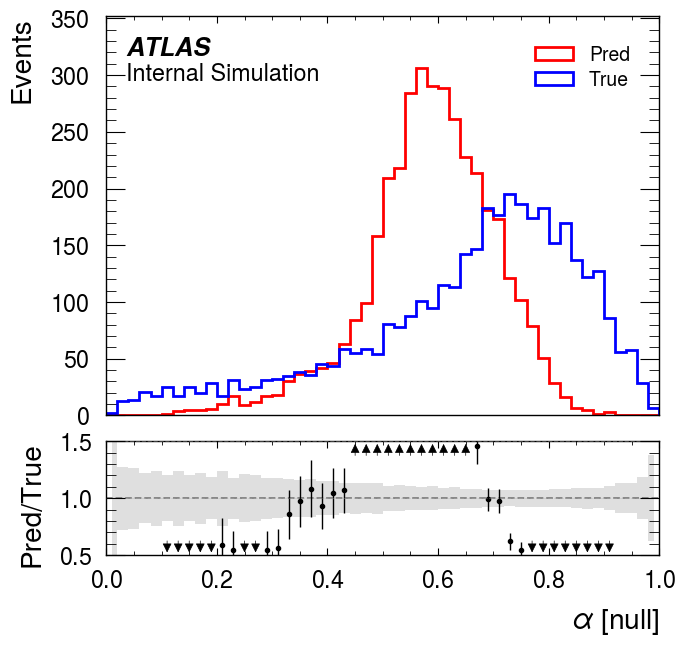

Rel err < 20%: 45.98 %


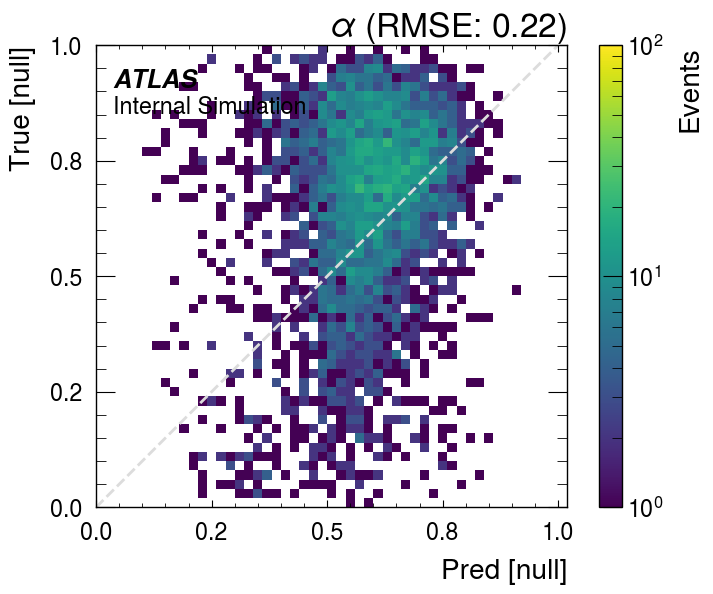

In [15]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [16]:
from ohbboosting import Booster

true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=1)
true_l0_p4 = np.stack([true_lep0_px,true_lep0_py,true_lep0_pz,true_lep0_energy], axis=1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=1)
true_l1_p4 = np.stack([true_lep1_px,true_lep1_py,true_lep1_pz,true_lep1_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# true_xi_pos, true_xi_neg = booster.lep_xi_in_w_rest()
# true_cglmp_bij = booster.cglmp_bij()

(3769, 16)


In [17]:
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=1)

particles = np.concatenate(
	[
		pred_w0_p4,
		true_l0_p4, # we can measure lepton 4-momentum precisely
		pred_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
pred_l0_theta_phi, pred_l1_theta_phi = booster.lep_theta_phi_in_w_rest()
# pred_xi_pos, pred_xi_neg = booster.lep_xi_in_w_rest()
# pred_cglmp_bij = booster.cglmp_bij()

(3769, 16)


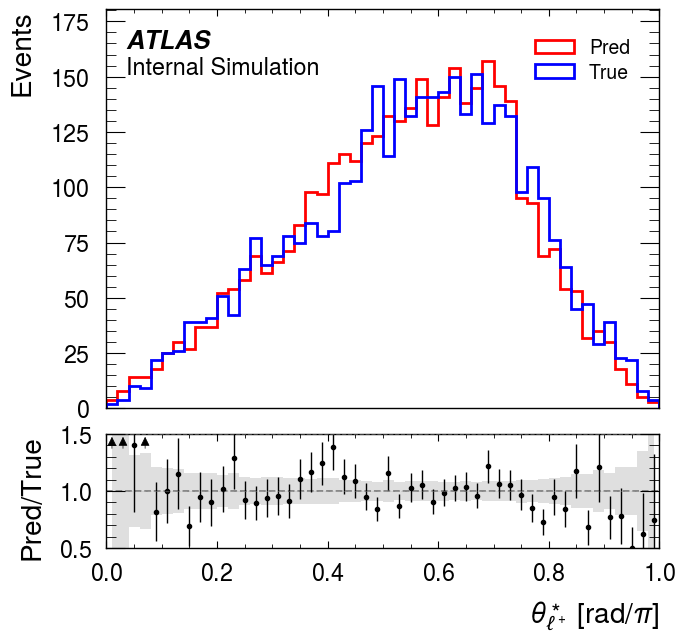

Rel err < 20%: 49.88 %


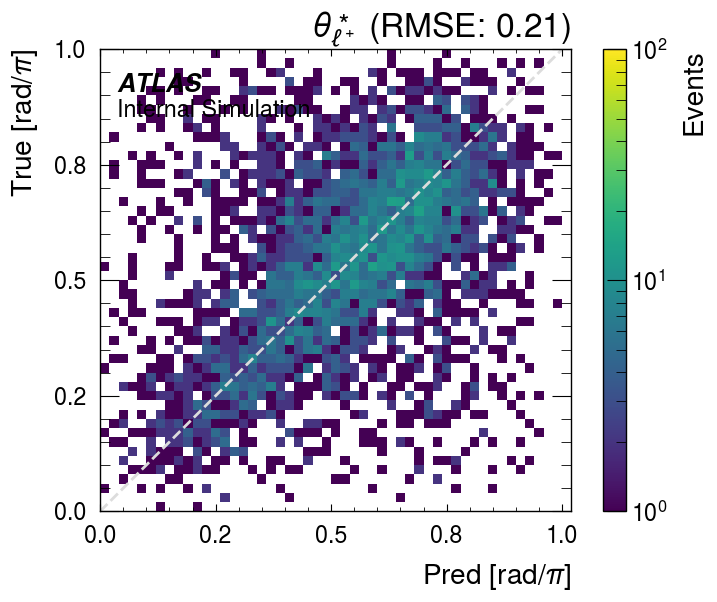

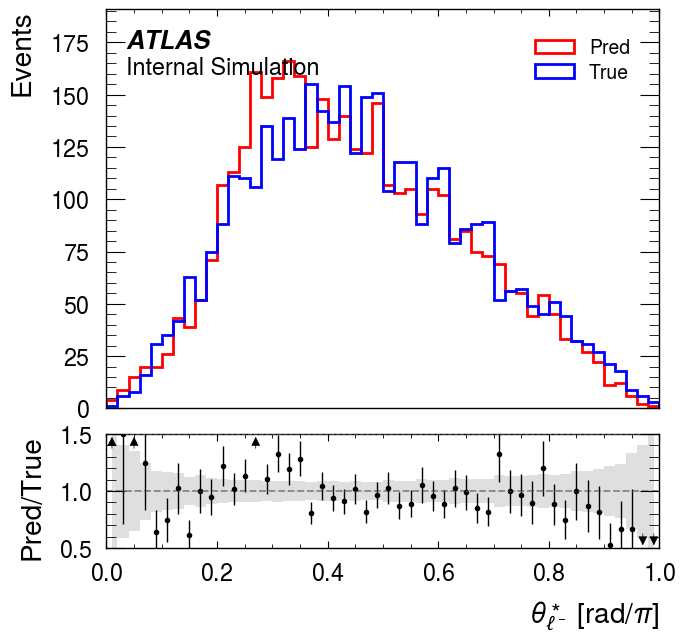

Rel err < 20%: 42.24 %


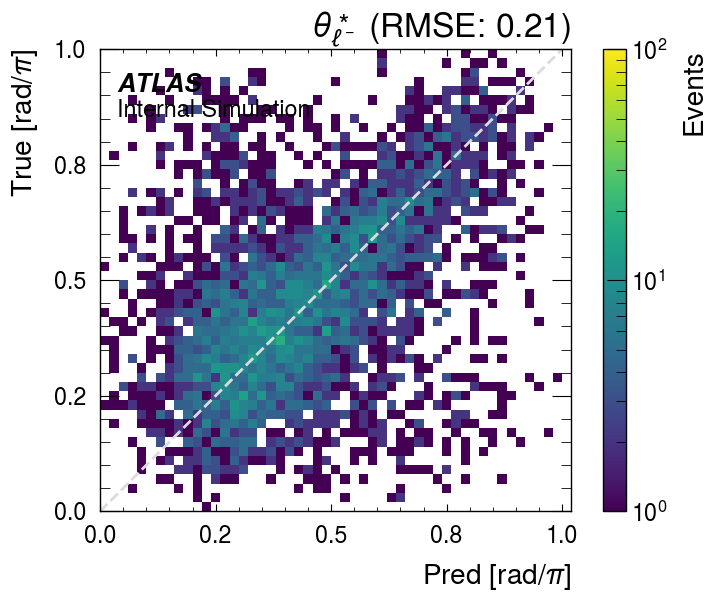

In [18]:
plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

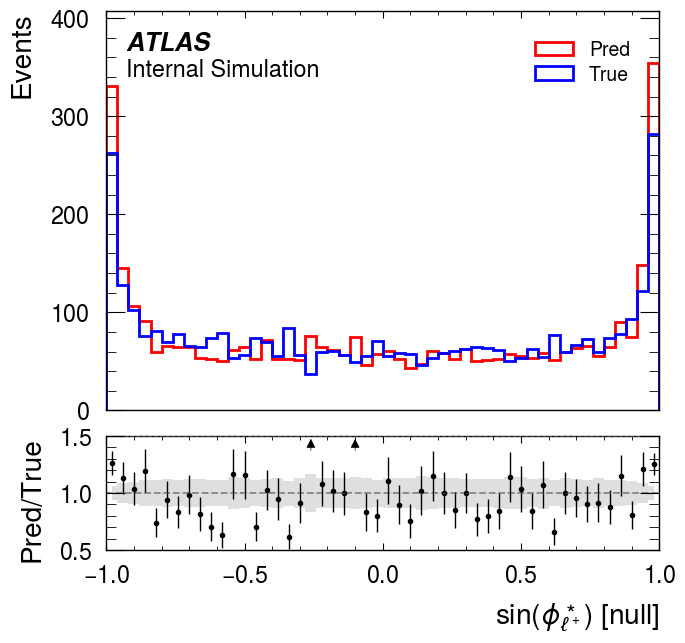

Rel err < 20%: 17.27 %


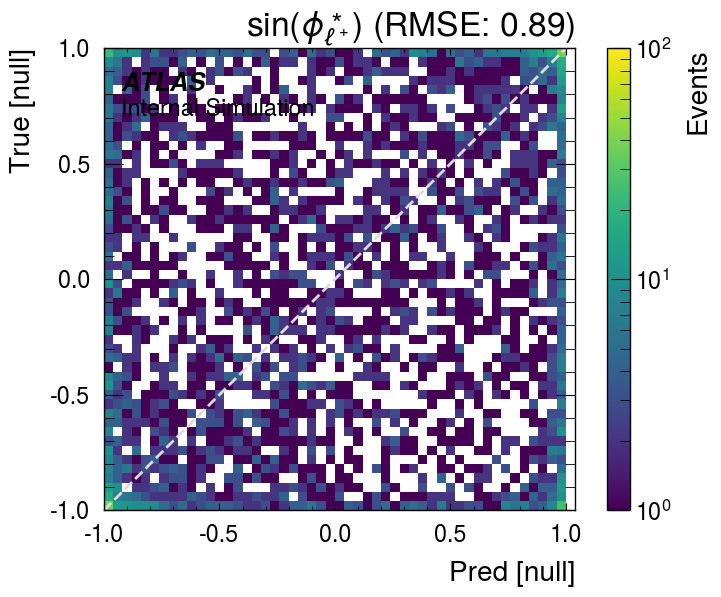

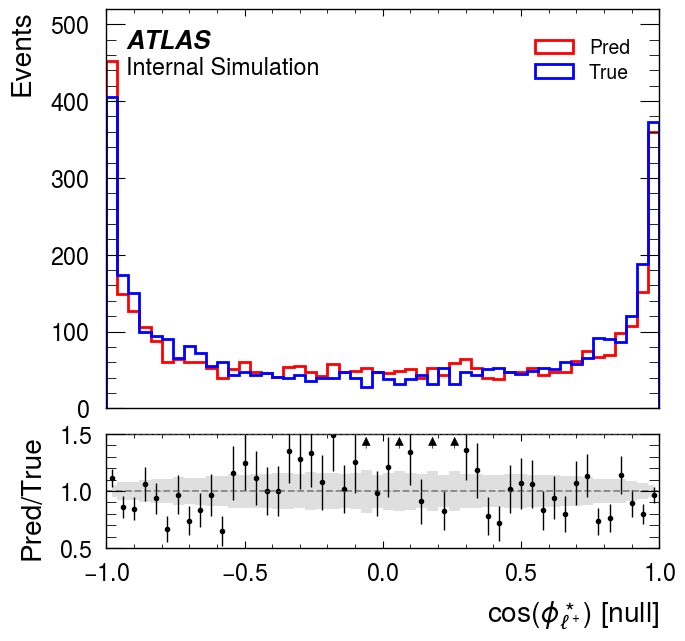

Rel err < 20%: 27.94 %


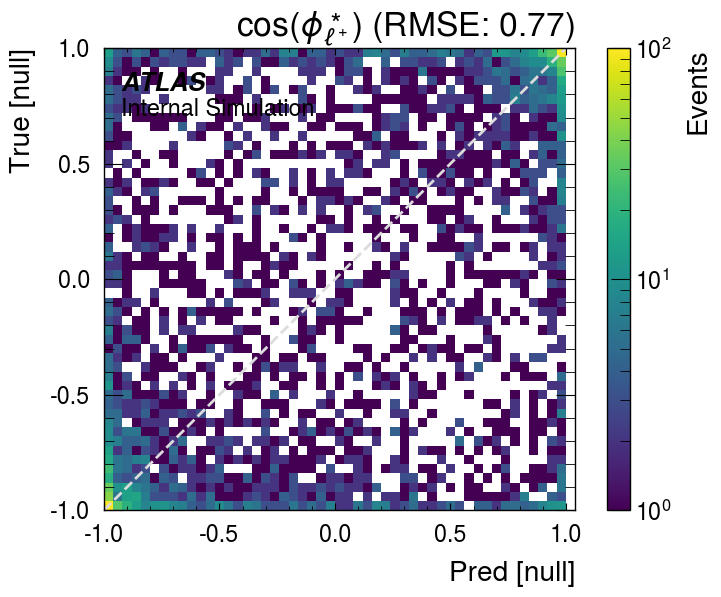

In [19]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), unit="null")
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)
plot_1d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), unit="null")
plot_2d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)

In [20]:
# plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), unit="null")
# plot_2d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 51), log=True, unit="null", color="black", vmax=1e2)

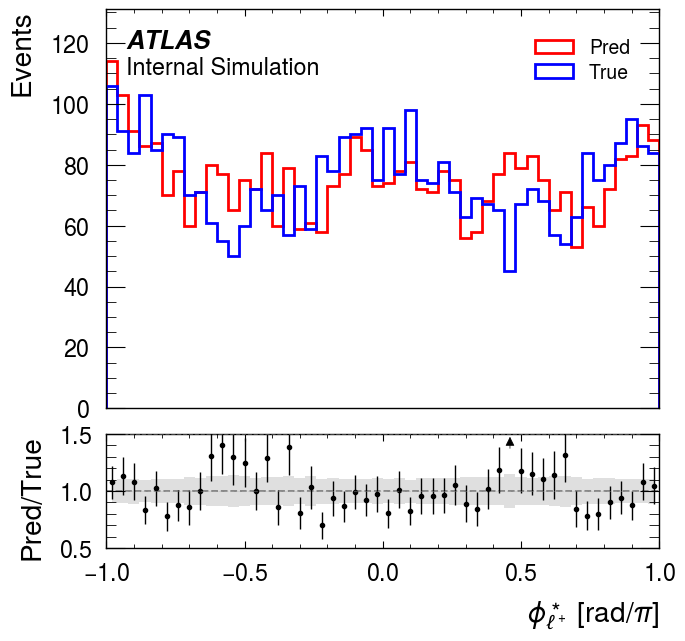

Rel err < 20%: 17.91 %


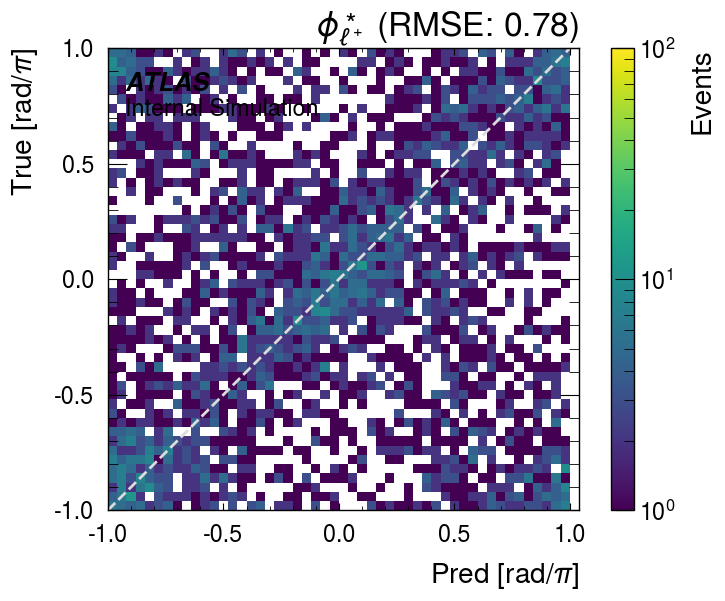

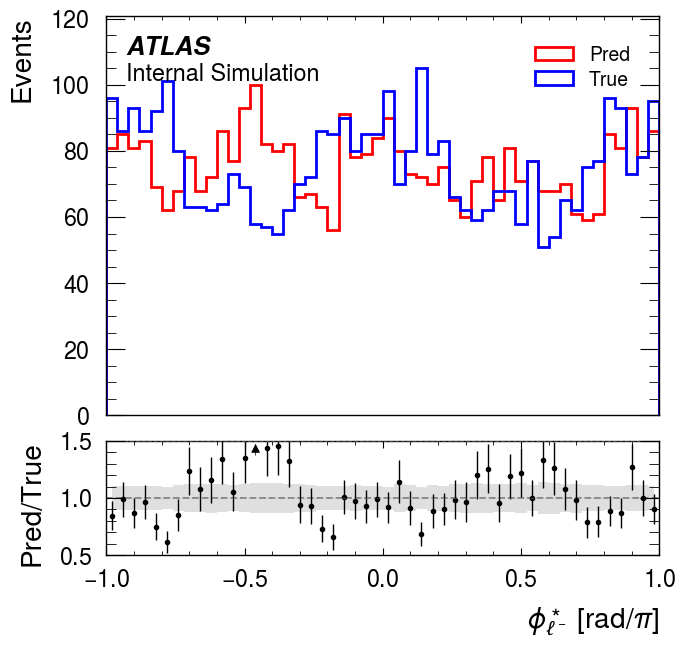

Rel err < 20%: 17.88 %


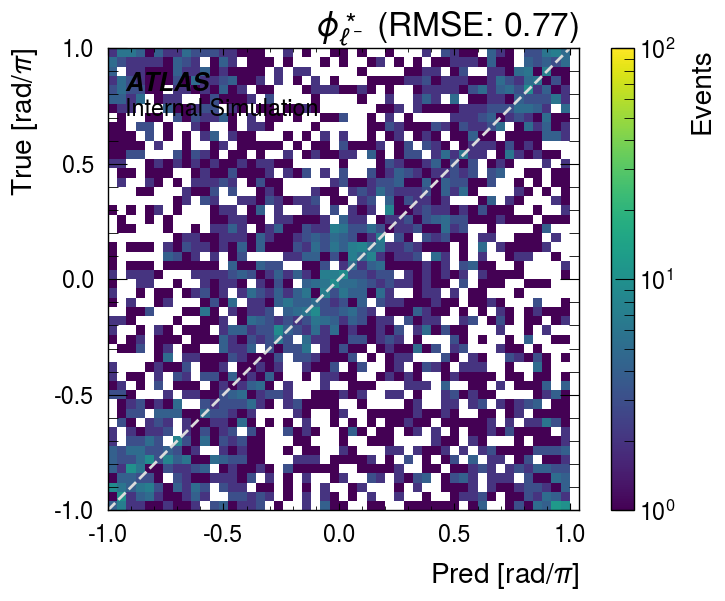

In [21]:
true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])

plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)
plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=1e2)

Found log directories: ['./hww_pcres_regressor_nofold/logs/version_0/']


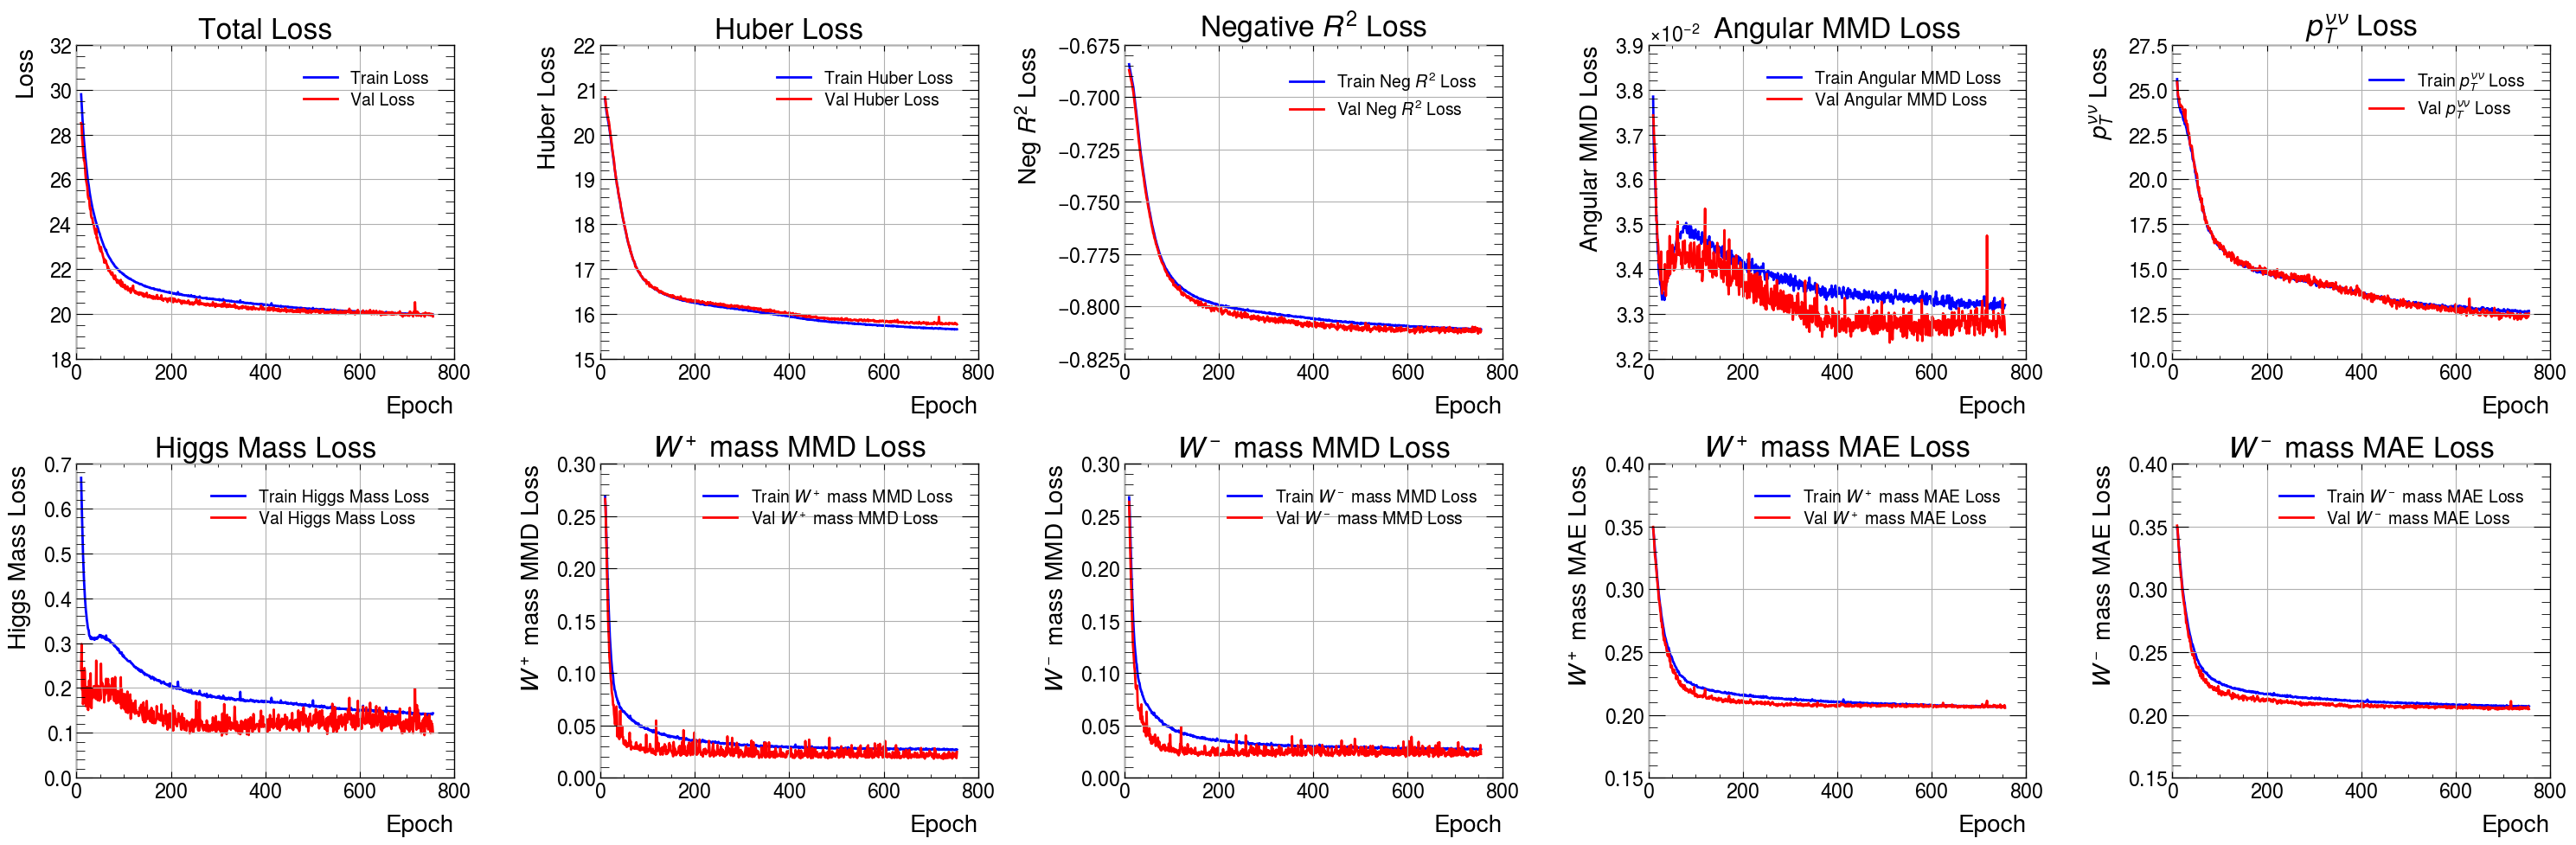

Final Training Losses (Epoch 755):
  Total Loss: 19.981493
  Huber Loss: 15.660284
  Negative $R^2$ Loss: -0.810879
  Angular MMD Loss: 0.033202
  $p^{\nu\nu}_T$ Loss: 12.671981
  Higgs Mass Loss: 0.143724
  $W^+$ mass MMD Loss: 0.026902
  $W^-$ mass MMD Loss: 0.027297
  $W^+$ mass MAE Loss: 0.206483
  $W^-$ mass MAE Loss: 0.206979
  $W^+$ mom MMD Loss: 0.018954
  $W^-$ mom MMD Loss: 0.019344
Final Validation Losses:
  Total Loss: 19.893957
  Huber Loss: 15.769533
  Negative $R^2$ Loss: -0.811786
  Angular MMD Loss: 0.032553
  $p^{\nu\nu}_T$ Loss: 12.531107
  Higgs Mass Loss: 0.100984
  $W^+$ mass MMD Loss: 0.024668
  $W^-$ mass MMD Loss: 0.022738
  $W^+$ mass MAE Loss: 0.205621
  $W^-$ mass MAE Loss: 0.204695
  $W^+$ mom MMD Loss: 0.018117
  $W^-$ mom MMD Loss: 0.018456


In [22]:
log_dirs = glob.glob(f"./hww_pcres_regressor_nofold/logs/version_0/")
print(f"Found log directories: {log_dirs}")
if not log_dirs:
    print("No logs found.")
else:
    metrics_path = os.path.join(log_dirs[0], "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {log_dirs[0]}")
    else:
        df = pd.read_csv(metrics_path)
        df_clean = df.copy()
        df_clean_train = (
            df_clean[df_clean["loss"].notna()] if "loss" in df_clean.columns else pd.DataFrame()
        )
        df_clean_val = (
            df_clean[df_clean["val_loss"].notna()] if "val_loss" in df_clean.columns else pd.DataFrame()
        )

        if df_clean_train.empty or df_clean_val.empty:
            print("Not enough training or validation records to visualize.")
        else:
            fig, axes = plt.subplots(2, 5, figsize=(30, 10))
            axes = axes.flatten()

            plot_configs = [
                ("loss", "val_loss", "Total Loss", "Loss"),
                ("huber_loss", "val_huber_loss", "Huber Loss", "Huber Loss"),
                ("neg_r2_loss", "val_neg_r2_loss", "Negative $R^2$ Loss", "Neg $R^2$ Loss"),
                # ("nu_mass_loss", "val_nu_mass_loss", "Neutrino Mass Loss", "Nu Mass Loss"),
                ("angular_loss_mmd_loss", "val_angular_loss_mmd_loss", "Angular MMD Loss", "Angular MMD Loss"),
                ("dinu_pt_loss", "val_dinu_pt_loss", r"$p^{\nu\nu}_T$ Loss", r"$p^{\nu\nu}_T$ Loss"),
                ("higgs_mass_loss", "val_higgs_mass_loss", "Higgs Mass Loss", "Higgs Mass Loss"),
                ("w_mass_mmd0_loss", "val_w_mass_mmd0_loss", "$W^+$ mass MMD Loss", "$W^+$ mass MMD Loss"),
                ("w_mass_mmd1_loss", "val_w_mass_mmd1_loss", "$W^-$ mass MMD Loss", "$W^-$ mass MMD Loss"),
                ("w0_mass_mae_loss", "val_w0_mass_mae_loss", "$W^+$ mass MAE Loss", "$W^+$ mass MAE Loss"),
                ("w1_mass_mae_loss", "val_w1_mass_mae_loss", "$W^-$ mass MAE Loss", "$W^-$ mass MAE Loss"),
                ("aux_mom_mmd0_loss", "val_aux_mom_mmd0_loss", "$W^+$ mom MMD Loss", "$W^+$ mom MMD Loss"),
                ("aux_mom_mmd1_loss", "val_aux_mom_mmd1_loss", "$W^-$ mom MMD Loss", "$W^-$ mom MMD Loss"),
            ]

            def apply_scale(ax, data):
                finite = data.replace([np.inf, -np.inf], np.nan).dropna()
                if finite.empty:
                    return
                if (finite <= 0).any():
                    ax.set_yscale("symlog", linthresh=1e-3)
                else:
                    ax.set_yscale("log")

            epochs_train = df_clean_train["epoch"].iloc[10:]
            epochs_val = df_clean_val["epoch"].iloc[10:]

            for ax, (train_col, val_col, title, ylabel) in zip(axes, plot_configs):
                if train_col not in df_clean_train.columns or val_col not in df_clean_val.columns:
                    ax.set_visible(False)
                    continue

                ax.plot(epochs_train, df_clean_train[train_col].iloc[10:], label=f"Train {ylabel}", color="blue")
                ax.plot(epochs_val, df_clean_val[val_col].iloc[10:], label=f"Val {ylabel}", color="red")
                ax.set_xlabel("Epoch")
                ax.set_ylabel(ylabel)
                ax.set_title(title)
                ax.legend()
                ax.grid(True)
                # apply_scale(ax, pd.concat([df_clean_train[train_col], df_clean_val[val_col]]))

            plt.tight_layout()
            plt.show()

            last_epoch = df_clean_train["epoch"].iloc[-1]
            print(f"Final Training Losses (Epoch {last_epoch}):")
            for train_col, _, title, _ in plot_configs:
                if train_col in df_clean_train.columns:
                    print(f"  {title}: {df_clean_train[train_col].iloc[-1]:.6f}")

            print("Final Validation Losses:")
            for _, val_col, title, _ in plot_configs:
                if val_col in df_clean_val.columns:
                    print(f"  {title}: {df_clean_val[val_col].iloc[-1]:.6f}")

In [23]:
# import shap
# import numpy as np
# import matplotlib as mpl
# from matplotlib import pyplot as plt

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Feature order follows load_data.py train_obj construction.
# feature_names = [
#     "lep+ px", "lep+ py", "lep+ pz", "lep+ energy",
#     "lep- px", "lep- py", "lep- pz", "lep- energy",
#     "jet1 px", "jet1 py", "jet1 pz", "jet1 energy",
#     "jet2 px", "jet2 py", "jet2 pz", "jet2 energy",
#     "MET px", "MET py",
#     "m_ll", "dilepton pt", "MET pt", "delta eta ll",
#     "delta phi ll-MET", "delta phi lep+-MET",
#     "delta phi lep--MET", "delta phi ll",
# ]

# output_names = [
#     "W+ px", "W+ py", "W+ pz", "W+ log energy",
#     "W- px", "W- py", "W- pz", "W- log energy",
# ]

# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# x_explain = samples_to_explain.detach().cpu().numpy()

# if len(feature_names) != x_explain.shape[1]:
#     raise ValueError(f"Expected {len(feature_names)} features, got {x_explain.shape[1]}")

# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# if isinstance(shap_values, list):
#     shap_values = np.stack(shap_values, axis=-1)

# importance_by_output = np.abs(shap_values).mean(axis=0)
# overall_importance = importance_by_output.mean(axis=1)
# top_overall = np.argsort(overall_importance)[::-1][:20]

# plt.figure(figsize=(9, 7))
# plt.barh(
#     [feature_names[idx] for idx in top_overall[::-1]],
#     overall_importance[top_overall[::-1]],
# )
# plt.xlabel("Mean |SHAP value| across outputs")
# plt.title("Overall SHAP Feature Importance", fontsize=15)
# plt.tight_layout()
# plt.show()

# heatmap_features = top_overall[::-1]
# plt.figure(figsize=(10, 8))
# plt.imshow(importance_by_output[heatmap_features], aspect="auto", cmap="viridis")
# plt.colorbar(label="Mean |SHAP value|")
# plt.yticks(range(len(heatmap_features)), [feature_names[idx] for idx in heatmap_features])
# plt.xticks(
#     range(min(len(output_names), importance_by_output.shape[1])),
#     output_names[:importance_by_output.shape[1]],
#     rotation=45,
#     ha="right",
# )
# plt.title("SHAP Importance by Feature and Output", fontsize=15)
# plt.tight_layout()
# plt.show()

# for i in range(shap_values.shape[-1]):
#     values = shap_values[:, :, i]
#     importance = importance_by_output[:, i]
#     top = np.argsort(importance)[::-1][:15]
#     output_label = output_names[i] if i < len(output_names) else f"output {i}"

#     print(f"Top features for {output_label}:")
#     for rank, idx in enumerate(top, start=1):
#         print(f"  {rank:2d}. {feature_names[idx]}: {importance[idx]:.6f}")

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="bar",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Feature Importance: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="dot",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Beeswarm: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()